2026-03-19 09:28:58,150 - [INFO] - Processing 'lexical_block_factor': 29 features.
/Users/daniel/Documents/dsdm_25-26/term_2/text_mining_nlp/term_paper/developmental-patterns-child-speech/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (200). n_quantiles is set to n_samples.
  warnings.warn(
2026-03-19 09:28:58,247 - [WARNING] - No features found for prefix syn_
2026-03-19 09:28:58,247 - [INFO] - Processing 'MEGA_FACTOR_1STAGE_EFA': 29 features.
/Users/daniel/Documents/dsdm_25-26/term_2/text_mining_nlp/term_paper/developmental-patterns-child-speech/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (200). n_quantiles is set to n_samples.
  warnings.warn(
/Users/daniel/Documents/dsdm_25-26/term_2/text_mining_nlp/term_paper/developmental-patterns-child-speech/.venv/lib/python3.13/site-packages/


========================================BLOCK: LEXICAL_BLOCK_FACTOR========================================
Anchors (3 features > 0.65 r with age_months):
  ['lex_svd_2', 'lex_score_late_complex', 'lex_score_cdi']... (showing up to 5)

Selection: Factor_4 (Purity Ratio: 1.64x)
Mean Anchor Loading: 0.747
Mean Non-Anchor Loading: 0.456
----------------------------------------
Anchor Weights on Factor_4:
lex_svd_2                -0.954300
lex_score_late_complex    0.756886
lex_score_cdi            -0.528398


========================================BLOCK: MEGA_FACTOR_1STAGE_EFA========================================
Anchors (3 features > 0.65 r with age_months):
  ['lex_svd_2', 'lex_score_late_complex', 'lex_score_cdi']... (showing up to 5)

Selection: Factor_4 (Purity Ratio: 1.64x)
Mean Anchor Loading: 0.747
Mean Non-Anchor Loading: 0.456
----------------------------------------
Anchor Weights on Factor_4:
lex_svd_2                -0.954300
lex_score_late_complex    0.756886
lex_score_

/var/folders/5t/fmr26qfn05g7zvmtmql3tyc00000gn/T/ipykernel_78347/218337270.py:242: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(valid_metrics))


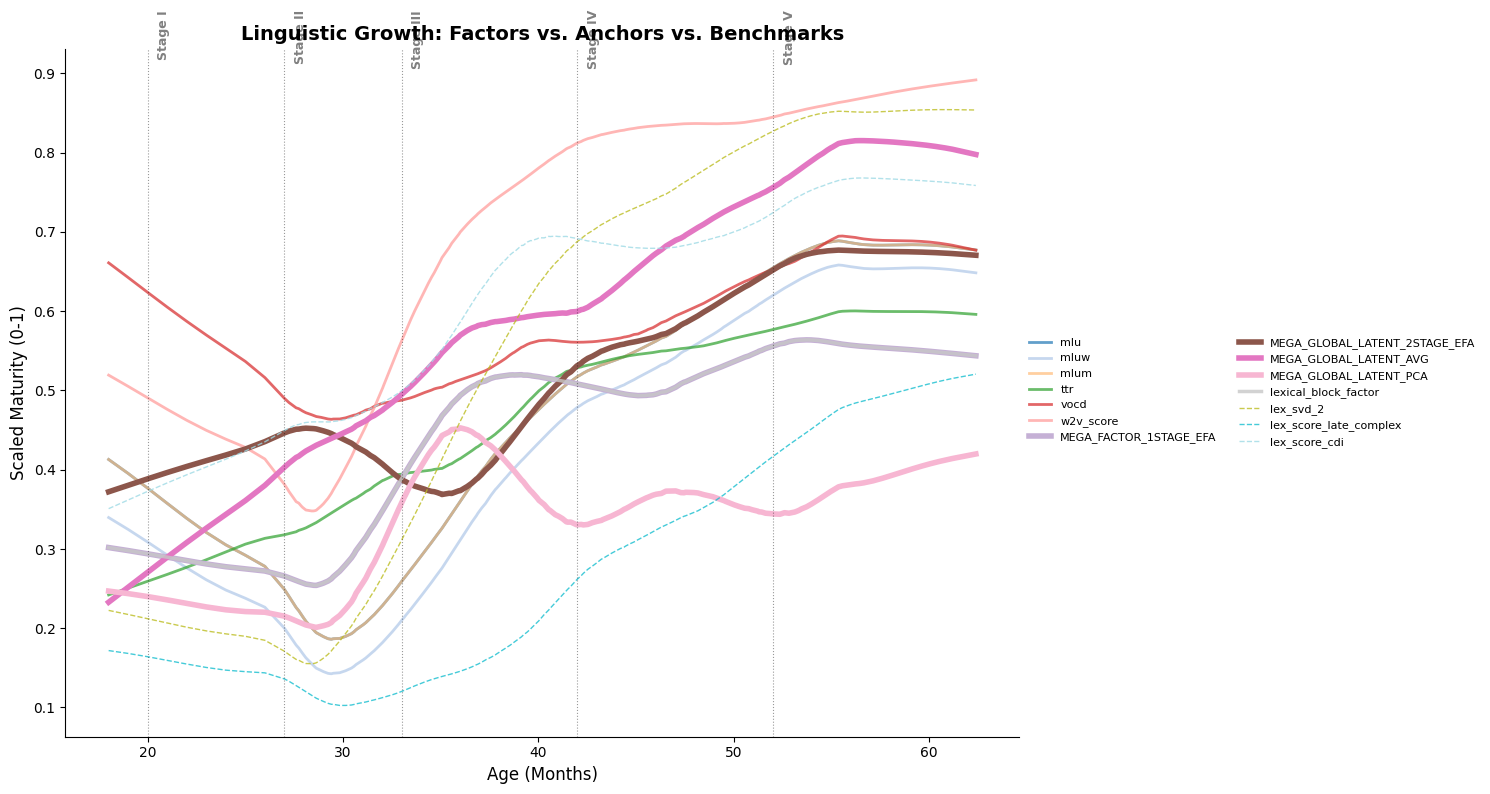

In [1]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt
from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.preprocessing import QuantileTransformer, StandardScaler, MinMaxScaler
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- Setup Logging ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s] - %(message)s')
logger = logging.getLogger(__name__)

# ==========================================
# --- CORE ENGINES ---
# ==========================================

def engineer_and_select_factor(
    df: pd.DataFrame, 
    feature_cols: list, 
    factor_name: str, 
    target: str = 'age_months', 
    threshold: float = 0.7, 
    n_factors: int = 5
):
    logger.info(f"Processing '{factor_name}': {len(feature_cols)} features.")
    df = df.copy()
    X = df[feature_cols].copy().fillna(df[feature_cols].median())
    
    actual_n_factors = min(n_factors, len(feature_cols))
    # Note: UserWarning for n_quantiles will trigger naturally if samples < 1000
    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    X_ranked = qt.fit_transform(X)
    
    fa = FactorAnalysis(n_components=actual_n_factors, random_state=42)
    factors = fa.fit_transform(X_ranked)
    
    loadings_df = pd.DataFrame(
        fa.components_.T, index=feature_cols, 
        columns=[f'Factor_{i+1}' for i in range(actual_n_factors)]
    )
    
    correlations = df[feature_cols + [target]].corr()[target].drop(target)
    
    # Identify Anchors
    current_thresh = threshold
    anchors = correlations[correlations.abs() >= current_thresh].index.tolist()
    while not anchors and current_thresh > 0.3:
        current_thresh -= 0.1
        anchors = correlations[correlations.abs() >= current_thresh].index.tolist()
        
    if not anchors:
        best_factor = 'Factor_1'
        purity_ratio = 1.0
        mean_anchor_loading = 0.0
        mean_non_anchor_loading = 0.0
    else:
        non_anchors = [f for f in feature_cols if f not in anchors]
        abs_loadings = loadings_df.abs()
        mean_anchor_loadings_per_factor = abs_loadings.loc[anchors].mean(axis=0)
        
        if non_anchors:
            mean_non_anchor_loadings_per_factor = abs_loadings.loc[non_anchors].mean(axis=0)
            purity_ratios = mean_anchor_loadings_per_factor / (mean_non_anchor_loadings_per_factor + 1e-9)
        else:
            purity_ratios = mean_anchor_loadings_per_factor 
            
        best_factor = purity_ratios.idxmax()
        purity_ratio = purity_ratios[best_factor]
        mean_anchor_loading = mean_anchor_loadings_per_factor[best_factor]
        mean_non_anchor_loading = mean_non_anchor_loadings_per_factor[best_factor] if non_anchors else 0.0

    # --- Print Block Summary as requested ---
    print(f"\n{'='*40}BLOCK: {factor_name.upper()}{'='*40}")
    print(f"Anchors ({len(anchors)} features > {current_thresh:.2f} r with {target}):")
    print(f"  {anchors[:5]}... (showing up to 5)")
    print(f"\nSelection: {best_factor} (Purity Ratio: {purity_ratio:.2f}x)")
    print(f"Mean Anchor Loading: {mean_anchor_loading:.3f}")
    if non_anchors:
        print(f"Mean Non-Anchor Loading: {mean_non_anchor_loading:.3f}")
    print("-" * 40)
    print(f"Anchor Weights on {best_factor}:")
    if anchors:
        print(loadings_df.loc[anchors, best_factor].to_string())
    print("=" * 82 + "\n")

    factor_idx = int(best_factor.split('_')[1]) - 1
    df[factor_name] = factors[:, factor_idx]
    
    if df[factor_name].corr(df[target]) < 0:
        df[factor_name] *= -1
        logger.info(f"Flipped {factor_name} to align positively with {target}.")
        
    return df, factor_name, anchors

# ==========================================
# --- PIPELINE PHASES ---
# ==========================================

def run_full_hierarchical_pipeline(
    df: pd.DataFrame, 
    block_prefixes: dict, 
    target: str = 'age_months', 
    mlu_col: str = 'mlu',
    extra_eval_cols: list = None,
    base_threshold: float = 0.65
):
    if extra_eval_cols is None:
        extra_eval_cols = ['mluw', 'mlum', 'ttr', 'vocd', 'mattr', 'w2v_score']
        
    processed_df = df.copy()
    generated_block_factors = []
    all_raw_features = []
    anchor_dict = {} 
    
    # --- PHASE 1: Block Level Reductions ---
    for block_name, prefix in block_prefixes.items():
        block_features = [
            c for c in processed_df.columns 
            if str(c).startswith(prefix) and pd.api.types.is_numeric_dtype(processed_df[c])
        ]
        if not block_features:
            logger.warning(f"No features found for prefix {prefix}")
            continue
            
        all_raw_features.extend(block_features)
        block_score_name = f"{block_name}_block_factor"
        
        processed_df, final_col_name, anchors = engineer_and_select_factor(
            processed_df, block_features, block_score_name, target, base_threshold
        )
        generated_block_factors.append(final_col_name)
        anchor_dict[final_col_name] = anchors

    mega_factors = []

    # --- PHASE 3: Multi-Factor Global EFA (Expanded) ---
    global_efa_subfactors = []
    if all_raw_features:
        # 1. Run the standard selection to get the primary MEGA_FACTOR_1STAGE_EFA
        processed_df, m_efa_1s, _ = engineer_and_select_factor(
            processed_df, all_raw_features, "MEGA_FACTOR_1STAGE_EFA", 
            target, base_threshold, 5
        )
        mega_factors.append(m_efa_1s)

        # 2. Explicitly extract all 5 latent factors from the global pool for further reduction
        # This mirrors the logic inside engineer_and_select_factor but keeps all components
        X = processed_df[all_raw_features].fillna(processed_df[all_raw_features].median())
        X_ranked = QuantileTransformer(output_distribution='normal', random_state=42).fit_transform(X)
        fa_global = FactorAnalysis(n_components=5, random_state=42)
        global_factors_raw = fa_global.fit_transform(X_ranked)
        
        for i in range(5):
            name = f"GLOBAL_EFA_SUBFACTOR_{i+1}"
            processed_df[name] = global_factors_raw[:, i]
            # Align each subfactor positively with age for consistency
            if processed_df[name].corr(processed_df[target]) < 0:
                processed_df[name] *= -1
            global_efa_subfactors.append(name)

    # --- ENHANCED REDUCTIONS (Applied to both Block-Level and Global-Latent pools) ---
    # We define the pools we want to reduce
    reduction_pools = {
        "BLOCK_LEVEL": generated_block_factors,
        "GLOBAL_LATENT": global_efa_subfactors
    }

    for pool_name, feature_list in reduction_pools.items():
        if len(feature_list) > 1:
            # PHASE 2 (Extended): Two-Stage EFA on this specific pool
            processed_df, m_efa_2s, _ = engineer_and_select_factor(
                processed_df, feature_list, f"MEGA_{pool_name}_2STAGE_EFA", 
                target, base_threshold-0.15, 3
            )
            mega_factors.append(m_efa_2s)

            # PHASE 4 (Extended): Equal-Weighted Average on this specific pool
            m_avg_name = f"MEGA_{pool_name}_AVG"
            scaler = StandardScaler()
            scaled_data = scaler.fit_transform(processed_df[feature_list])
            processed_df[m_avg_name] = scaled_data.sum(axis = 1) # .mean(axis=1)
            if processed_df[m_avg_name].corr(processed_df[target]) < 0:
                processed_df[m_avg_name] *= -1
            mega_factors.append(m_avg_name)

            # PHASE 5 (Extended): PCA on this specific pool
            m_pca_name = f"MEGA_{pool_name}_PCA"
            pca = PCA(n_components=1, random_state=42)
            processed_df[m_pca_name] = pca.fit_transform(scaled_data)[:, 0]
            if processed_df[m_pca_name].corr(processed_df[target]) < 0:
                processed_df[m_pca_name] *= -1
            mega_factors.append(m_pca_name)
            
            logger.info(f"Completed Phase 2, 4, and 5 for {pool_name} pool.")
        else:
            logger.warning(f"Skipping reductions for {pool_name}: Pool size is {len(feature_list)}.")

    # Final Evaluation Matrix
    all_factor_cols = list(dict.fromkeys(mega_factors + generated_block_factors))
    benchmark_cols = [target, mlu_col] + [c for c in extra_eval_cols if c in processed_df.columns]
    
    print("\n" + "="*50 + "\nFINAL CORRELATION EVALUATION\n" + "="*50)
    print(processed_df[all_factor_cols + benchmark_cols].corr().loc[all_factor_cols, benchmark_cols].round(3))
    
    return processed_df, all_factor_cols, anchor_dict

# ==========================================
# --- ANALYTICS & VISUALIZATION ---
# ==========================================

def analyze_and_visualize_growth(
    df: pd.DataFrame, 
    factor_cols: list, 
    anchor_dict: dict,
    extra_metrics: list,
    stage_col: str = 'brown_stage',
    target_age: str = 'age_months'
):
    all_anchors = list(set([item for sublist in anchor_dict.values() for item in sublist]))
    metric_cols = [c for c in (extra_metrics + factor_cols + all_anchors) if c != target_age]
    valid_metrics = [c for c in metric_cols if c in df.columns]
    
    # 1. Transform metrics for positive growth alignment
    plot_df = df.copy().sort_values(target_age)
    for col in valid_metrics:
        correlation = plot_df[col].corr(plot_df[target_age])
        if correlation < 0:
            plot_df[col] = plot_df[col] * -1
            # logger.info(f"Aligned plotting for {col} (flipped negative correlation).")

    # 2. Table: Mean Scores by Brown Stage
    print(f"\n{'='*80}\nMEAN SCORES BY {stage_col.upper()}\n{'='*80}")
    stage_summary = plot_df.groupby(stage_col)[valid_metrics].mean().sort_index().T
    print(stage_summary.round(3).to_string())

    # 3. Plot: LOWESS Trajectories
    scaler = MinMaxScaler()
    plot_df[valid_metrics] = scaler.fit_transform(plot_df[valid_metrics])
    
    fig, ax = plt.subplots(figsize=(15, 8))
    ages = plot_df[target_age].values 
    colors = plt.cm.get_cmap('tab20', len(valid_metrics))

    for i, col in enumerate(valid_metrics):
        y = plot_df[col].values
        smoothed = lowess(y, ages, frac=0.3)
        
        if "MEGA" in col:
            lw, ls, alpha = 4.0, '-', 1.0
        elif "block_factor" in col:
            lw, ls, alpha = 2.5, '-', 0.8
        elif col in all_anchors:
            lw, ls, alpha = 1, '--', 0.8
        else:
            lw, ls, alpha = 2.0, '-', 0.7

        ax.plot(smoothed[:, 0], smoothed[:, 1], label=col, color=colors(i), 
                linewidth=lw, linestyle=ls, alpha=alpha)

    stage_markers = {'I': 20, 'II': 27, 'III': 33, 'IV': 42, 'V': 52}
    for stage, age_val in stage_markers.items():
        ax.axvline(age_val, color='black', lw=0.8, ls=':', alpha=0.4)
        ax.text(age_val + 0.5, 0.98, f"Stage {stage}", fontsize=9, 
                rotation=90, va='top', color='grey', fontweight='bold')

    ax.set_title("Linguistic Growth: Factors vs. Anchors vs. Benchmarks", fontsize=14, fontweight='bold')
    ax.set_xlabel("Age (Months)", fontsize=12)
    ax.set_ylabel("Scaled Maturity (0-1)", fontsize=12)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8, 
              ncol=2 if len(valid_metrics) > 12 else 1, frameon=False)
    
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

# ==========================================
# --- SAMPLE IMPLEMENTATION ---
# ==========================================

# import data
master_df = pd.read_csv('../data/processed/master_features_with_rrl.csv')
exclude_cols = [ 'child_id', 'age_months', 'mlu', 'mluw', 'mlum', 'ttr', 'mattr', 'brown_stage','vocd',	'w2v_score', 'mixture_cluster', 'sess_id', 'exp', 'lang']
feature_cols = [ col for col in master_df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(master_df[col])]

rename_dict = {
    col: f"lex_{col}" 
    for col in master_df.columns 
    if col in feature_cols
}

master_df = master_df.rename(columns=rename_dict)

blocks_to_process = {
    'lexical': 'lex_'
}

final_df, factor_list, anchor_map = run_full_hierarchical_pipeline(
    df=master_df, 
    block_prefixes={'lexical': 'lex_', 'syntactic': 'syn_'},
    target='age_months',
    mlu_col='mlu'
)

analyze_and_visualize_growth(
    df=final_df,
    factor_cols=factor_list,
    anchor_dict=anchor_map,
    extra_metrics=['age_months', 'mlu', 'mluw', 'mlum', 'ttr', 'vocd', 'w2v_score'],
    stage_col='brown_stage'
)

In [2]:
factor_list

['MEGA_FACTOR_1STAGE_EFA',
 'MEGA_GLOBAL_LATENT_2STAGE_EFA',
 'MEGA_GLOBAL_LATENT_AVG',
 'MEGA_GLOBAL_LATENT_PCA',
 'lexical_block_factor']

In [3]:
final_df

,child_id,age_months,mlu,mlum,mluw,ttr,brown_stage,vocd,mattr,w2v_score,...,lexical_block_factor,MEGA_FACTOR_1STAGE_EFA,GLOBAL_EFA_SUBFACTOR_1,GLOBAL_EFA_SUBFACTOR_2,GLOBAL_EFA_SUBFACTOR_3,GLOBAL_EFA_SUBFACTOR_4,GLOBAL_EFA_SUBFACTOR_5,MEGA_GLOBAL_LATENT_2STAGE_EFA,MEGA_GLOBAL_LATENT_AVG,MEGA_GLOBAL_LATENT_PCA
0,Eve,18.000000,1.43,1.43,1.50,0.245714,I,69.265261,0.434420,0.825856,...,-1.308674,-1.308674,-0.375774,-0.590066,-1.136538,-1.308674,-0.312907,-0.777658,-3.813372,-0.689978
1,Eve,19.000000,2.14,2.14,2.16,0.342857,II,74.630866,0.504271,0.724007,...,-1.110576,-1.110576,-0.364912,-0.560058,-1.286377,-1.110576,-0.098689,-0.635683,-3.492957,-0.704465
2,Eve,20.000000,2.16,2.16,2.19,0.294286,II,86.661512,0.518242,0.591027,...,-1.135264,-1.135264,-0.373852,-0.542979,-1.422344,-1.135264,-0.172140,-0.760075,-3.727495,-0.664232
3,Eve,21.000000,2.38,2.38,2.42,0.334286,II,96.471548,0.521927,0.429027,...,-1.893605,-1.893605,-0.402389,-0.401651,-4.211603,-1.893605,0.178924,-1.468850,-6.868261,-1.422072
4,Eve,22.000000,2.85,2.85,2.85,0.331429,III,75.033983,0.544519,0.242227,...,-0.941421,-0.941421,-0.358408,-0.546687,-1.876599,-0.941421,-0.285986,-0.827386,-4.102394,-0.427724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Sarah,60.333333,2.87,2.87,2.89,0.420000,III,67.287603,0.647154,-0.589382,...,0.763769,0.763769,-0.180091,-0.570050,-0.316577,0.763769,1.662080,0.828989,1.480445,-0.689801
196,Sarah,60.533333,3.79,3.79,3.80,0.391429,V,83.673752,0.690370,-0.478215,...,0.236163,0.236163,1.774558,0.775688,-0.255146,0.236163,0.307359,0.937977,2.877073,-0.052492
197,Sarah,60.833333,3.05,3.05,3.06,0.411429,IV,69.301842,0.663976,-0.524533,...,0.756361,0.756361,-0.192723,-0.601526,-0.596028,0.756361,1.185638,0.660085,0.633861,-0.329763
198,Sarah,61.000000,3.76,3.76,3.76,0.422857,V,76.212073,0.680624,-0.467450,...,0.686111,0.686111,-0.202820,-0.655231,0.055397,0.686111,0.955543,0.717870,0.917303,-0.220860


In [4]:
final_df.columns

Index(['child_id', 'age_months', 'mlu', 'mlum', 'mluw', 'ttr', 'brown_stage',
       'vocd', 'mattr', 'w2v_score', 'lex_svd_1', 'lex_svd_2', 'lex_svd_3',
       'lex_svd_4', 'lex_svd_5', 'lex_svd_6', 'lex_svd_7', 'lex_svd_8',
       'lex_svd_9', 'lex_svd_10', 'lex_score_early_nouns',
       'lex_score_action_words', 'lex_score_social_words',
       'lex_score_descriptors', 'lex_score_late_complex', 'lex_score_cdi',
       'lex_topic_early_nouns', 'lex_topic_action_words',
       'lex_topic_social_words', 'lex_topic_descriptors',
       'lex_topic_late_complex', 'mixture_cluster', 'lex_mix_prob_1',
       'lex_mix_prob_2', 'lex_mix_prob_3', 'lex_mix_prob_4', 'lex_mix_prob_5',
       'lex_mix_prob_6', 'lex_mix_prob_7', 'lex_mix_prob_8',
       'lexical_block_factor', 'MEGA_FACTOR_1STAGE_EFA',
       'GLOBAL_EFA_SUBFACTOR_1', 'GLOBAL_EFA_SUBFACTOR_2',
       'GLOBAL_EFA_SUBFACTOR_3', 'GLOBAL_EFA_SUBFACTOR_4',
       'GLOBAL_EFA_SUBFACTOR_5', 'MEGA_GLOBAL_LATENT_2STAGE_EFA',
       'MEGA_G


MEAN SCORES BY BROWN_STAGE
brown_stage                        I     II    III     IV      V
GLOBAL_EFA_SUBFACTOR_1        -0.699 -0.422  0.260  0.498  0.213
GLOBAL_EFA_SUBFACTOR_2         0.086  0.380  0.083 -0.079 -0.444
GLOBAL_EFA_SUBFACTOR_3         0.933 -0.885 -0.471 -0.156  0.470
GLOBAL_EFA_SUBFACTOR_4        -1.077 -0.391 -0.103  0.383  1.209
GLOBAL_EFA_SUBFACTOR_5        -0.161 -0.054  0.380 -0.057 -0.046
MEGA_FACTOR_1STAGE_EFA        -1.077 -0.391 -0.103  0.383  1.209
MEGA_GLOBAL_LATENT_2STAGE_EFA -0.540 -0.630  0.017  0.317  0.767
MEGA_GLOBAL_LATENT_AVG        -0.940 -1.405  0.163  0.594  1.439
MEGA_GLOBAL_LATENT_PCA        -0.684 -0.228 -0.351  0.327  0.906
lexical_block_factor          -1.077 -0.391 -0.103  0.383  1.209


/var/folders/5t/fmr26qfn05g7zvmtmql3tyc00000gn/T/ipykernel_78347/218337270.py:242: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(valid_metrics))


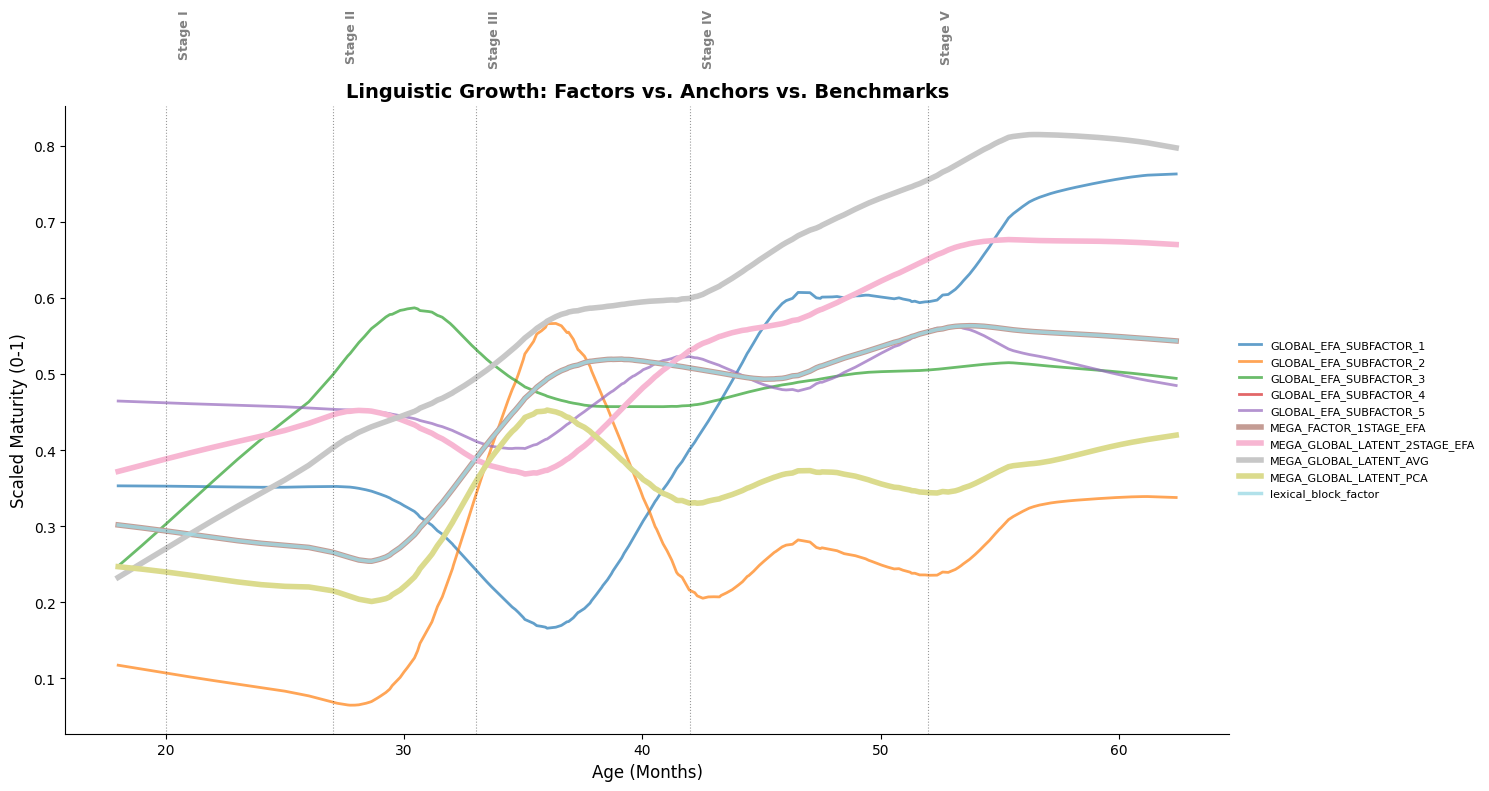

In [5]:
analyze_and_visualize_growth(
    df=final_df,
    factor_cols=factor_list,
    anchor_dict={},
    extra_metrics=['age_months', 'GLOBAL_EFA_SUBFACTOR_1', 'GLOBAL_EFA_SUBFACTOR_2',
       'GLOBAL_EFA_SUBFACTOR_3', 'GLOBAL_EFA_SUBFACTOR_4',
       'GLOBAL_EFA_SUBFACTOR_5'],
    stage_col='brown_stage'
)

In [6]:
final_df[['GLOBAL_EFA_SUBFACTOR_1', 'GLOBAL_EFA_SUBFACTOR_2',
       'GLOBAL_EFA_SUBFACTOR_3', 'GLOBAL_EFA_SUBFACTOR_4',
       'GLOBAL_EFA_SUBFACTOR_5']].describe()

,GLOBAL_EFA_SUBFACTOR_1,GLOBAL_EFA_SUBFACTOR_2,GLOBAL_EFA_SUBFACTOR_3,GLOBAL_EFA_SUBFACTOR_4,GLOBAL_EFA_SUBFACTOR_5
count,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,0.000000,-3.197442e-16,-6.217249e-17,3.552714e-17,1.421085e-16
std,0.996993,9.937901e-01,9.809637e-01,9.757736e-01,9.385117e-01
min,-1.530961,-8.785545e-01,-4.211603e+00,-2.889381e+00,-3.184631e+00
25%,-0.365333,-6.999122e-01,-4.951850e-01,-4.828763e-01,-5.500848e-01
50%,-0.252219,-5.801377e-01,2.702379e-02,4.861288e-02,-1.527141e-01
75%,-0.161632,7.448045e-01,5.641258e-01,4.617533e-01,4.222875e-01
max,1.816765,2.165312e+00,4.443803e+00,3.116906e+00,3.314652e+00


In [7]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [8]:
# ⚠️ Replace `final_df` with your actual variable name from NB06
df = final_df.copy()

age = df["age_months"].values
mlu = df["mlu"].values

svd_cols    = [f"lex_svd_{i}" for i in range(1, 11)]
dict_cols   = [f"lex_score_{c}" for c in
               ["early_nouns","action_words","social_words",
                "descriptors","late_complex","cdi"]]
topic_cols  = [f"lex_topic_{c}" for c in
               ["early_nouns","action_words","social_words",
                "descriptors","late_complex"]]
rrl_cols    = [c for c in ["mlu","vocd","mattr","w2v_score"] if c in df.columns]
latent_cols = [c for c in
               ["lexical_block_factor","MEGA_FACTOR_1STAGE_EFA",
                "MEGA_GLOBAL_LATENT_2STAGE_EFA","MEGA_GLOBAL_LATENT_AVG",
                "MEGA_GLOBAL_LATENT_PCA"]
               if c in df.columns]

rename = {**{f"lex_svd_{i}": f"svd_{i}" for i in range(1,11)},
          **{f"lex_score_{c}": f"score_{c}" for c in
             ["early_nouns","action_words","social_words","descriptors","late_complex","cdi"]},
          **{f"lex_topic_{c}": f"topic_{c}" for c in
             ["early_nouns","action_words","social_words","descriptors","late_complex"]}}

pipeline_map = (
    {c: "SVD"           for c in svd_cols}   |
    {c: "Dictionary"    for c in dict_cols}  |
    {c: "Seeded LDA"    for c in topic_cols} |
    {c: "RRL Baseline"  for c in rrl_cols}   |
    {c: "Latent (NB06)" for c in latent_cols}
)

rows = []
for col in svd_cols + dict_cols + topic_cols + rrl_cols + latent_cols:
    if col not in df.columns:
        continue
    vals  = df[col].values.astype(float)
    valid = ~np.isnan(vals)
    r_age, p_age = spearmanr(age[valid], vals[valid])
    r_mlu, p_mlu = spearmanr(mlu[valid], vals[valid])
    rows.append({"feature": rename.get(col, col), "pipeline": pipeline_map[col],
                 "r_age": round(r_age,3), "p_age": round(p_age,4),
                 "sig_age": "✅" if p_age < 0.05 else "❌",
                 "r_mlu": round(r_mlu,3), "sig_mlu": "✅" if p_mlu < 0.05 else "❌"})

h1 = pd.DataFrame(rows).sort_values("r_age", key=abs, ascending=False)
print(h1[["feature","pipeline","r_age","p_age","sig_age"]].to_string(index=False))

                      feature      pipeline  r_age  p_age sig_age
                        svd_2           SVD -0.888 0.0000       ✅
       MEGA_GLOBAL_LATENT_AVG Latent (NB06)  0.823 0.0000       ✅
MEGA_GLOBAL_LATENT_2STAGE_EFA Latent (NB06)  0.810 0.0000       ✅
                        mattr  RRL Baseline  0.791 0.0000       ✅
           score_late_complex    Dictionary  0.785 0.0000       ✅
                    w2v_score  RRL Baseline -0.760 0.0000       ✅
                    score_cdi    Dictionary -0.719 0.0000       ✅
                          mlu  RRL Baseline  0.719 0.0000       ✅
       MEGA_FACTOR_1STAGE_EFA Latent (NB06)  0.638 0.0000       ✅
         lexical_block_factor Latent (NB06)  0.638 0.0000       ✅
            score_early_nouns    Dictionary -0.633 0.0000       ✅
           topic_social_words    Seeded LDA  0.626 0.0000       ✅
            topic_early_nouns    Seeded LDA  0.592 0.0000       ✅
                        svd_1           SVD  0.529 0.0000       ✅
          

/var/folders/5t/fmr26qfn05g7zvmtmql3tyc00000gn/T/ipykernel_78347/3344365079.py:21: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5t/fmr26qfn05g7zvmtmql3tyc00000gn/T/ipykernel_78347/3344365079.py:21: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5t/fmr26qfn05g7zvmtmql3tyc00000gn/T/ipykernel_78347/3344365079.py:22: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("../figures/H1_spearman_all_v4.png", dpi=150, bbox_inches="tight")
/var/folders/5t/fmr26qfn05g7zvmtmql3tyc00000gn/T/ipykernel_78347/3344365079.py:22: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("../figures/H1_spearman_all_v4.png", dpi=150, bbox_inches="tight")
/Users/daniel/Documents/dsdm_25-26/term_2/text_mining_nlp/term_paper/developmental-patterns-child-speech/.venv/lib/python3.13/site-package

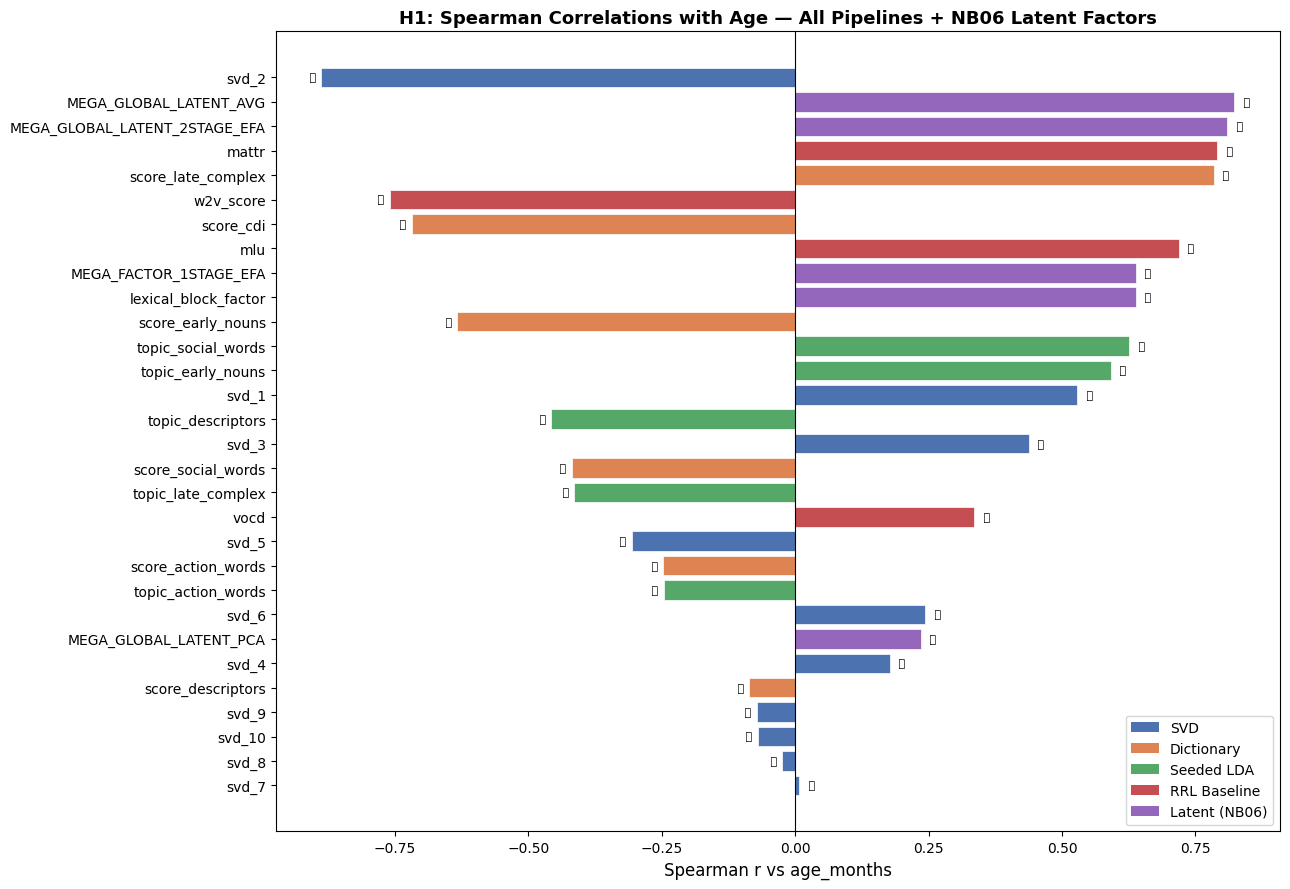

In [9]:
colors = {"SVD": "#4C72B0", "Dictionary": "#DD8452", "Seeded LDA": "#55A868",
          "RRL Baseline": "#C44E52", "Latent (NB06)": "#9467BD"}

fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(h1["feature"], h1["r_age"],
        color=[colors[p] for p in h1["pipeline"]],
        edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)

for i, (_, row) in enumerate(h1.iterrows()):
    x = row["r_age"]
    ax.text(x + (0.01 if x >= 0 else -0.01), i, " " + row["sig_age"],
            va="center", ha="left" if x >= 0 else "right", fontsize=8)

ax.legend(handles=[Patch(facecolor=v, label=k) for k, v in colors.items()],
          loc="lower right", fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Spearman r vs age_months", fontsize=12)
ax.set_title("H1: Spearman Correlations with Age — All Pipelines + NB06 Latent Factors",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/H1_spearman_all_v4.png", dpi=150, bbox_inches="tight")
plt.show()